Adjacency in vertical splitting
===============================

Let's start by doing some imports and defining the data

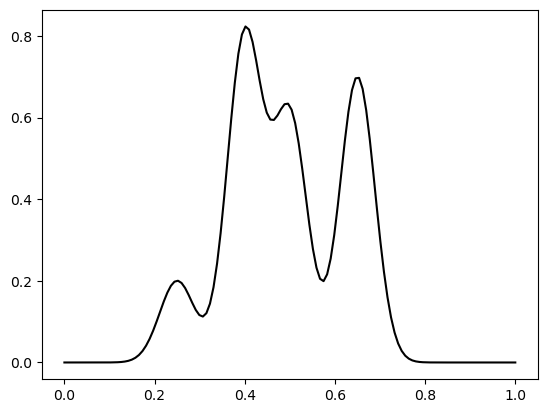

In [1]:
import heat as ht
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data
from astrodendro.dendrogram import Dendrogram

x, data = get_1d_data(128)
plt.plot(x.larray, data.larray, color="black")

Next, we define the vertical split.
To this end, we need to sort the data and then get local data by applying a slice on the sorted indices.
We include a halo, so that we can later tell more easily how to merge structures from adjacent dendrograms

In [2]:
ntasks = 4
elements_per_task = int(np.ceil(data.shape[0] / ntasks))
halo_size = 4

In [3]:
local_slices = [
    slice(i * elements_per_task, (i + 1) * elements_per_task) for i in range(ntasks)
]
for i in range(ntasks):
    start = i * elements_per_task
    stop = start + elements_per_task
    if i > 0:
        start -= halo_size
    if i < ntasks - 1:
        stop += halo_size
    local_slices[i] = slice(start, stop)

In [4]:
idx = np.argsort(data.numpy())
local_idx = [
    sorted(idx[s]) for s in local_slices
]  # we need to sort the indices to express adjacency for the subsequent dendrogram computation
local_data = [data[idx] for idx in local_idx]

Let's see the data on each task

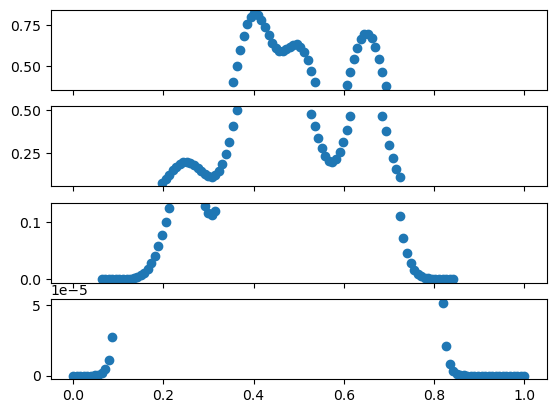

In [5]:
fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    axs[-i - 1].scatter(x[local_idx[i]], local_data[i])

But astrodendro doesn't see the spacial coordinate.
We give to astrodendro the following data, where all data on each level is a chain of adjacent data.
This is important to get the global tree structure right!

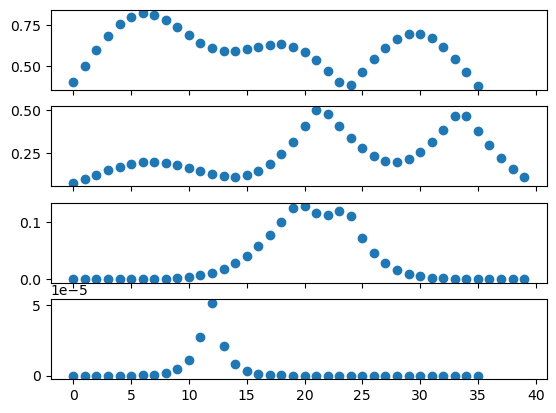

In [6]:
fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    axs[-i - 1].scatter(np.arange(len(local_data[i])), local_data[i])

To illustrate, let's compute the local dendrograms

In [7]:
local_dendrograms = [Dendrogram.compute(_data.numpy()) for _data in local_data]

Before we continue, we have to map the local indices in the local dendrograms to global indices

In [8]:
def local_to_global_index(_local_idx, leaves):
    for leaf in leaves:
        leaf._indices = [_local_idx[i[0]] for i in leaf._indices]
        local_to_global_index(_local_idx=_local_idx, leaves=leaf._children)


for i in range(ntasks):
    local_to_global_index(local_idx[i], local_dendrograms[i].trunk)

Let's plot the local dendrograms

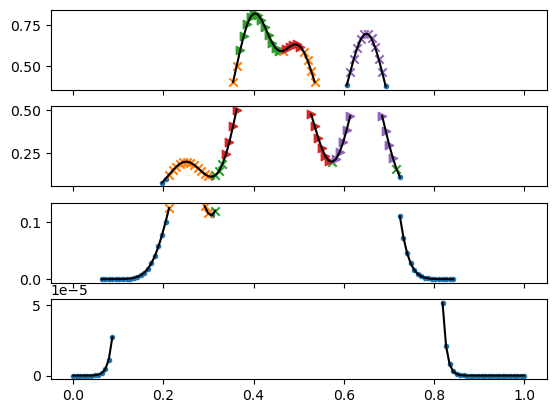

In [9]:
def plot_astrodendro_leaves(ax, leaves, level=0):
    markers = {0: ".", 1: "x", 2: ">", 3: "o", 4: "<"}
    for leaf in leaves:
        ax.scatter(
            x.numpy()[leaf._indices],
            data.numpy()[leaf._indices],
            marker=markers[level],
        )
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)


fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    ax = axs[-i - 1] if ntasks > 1 else axs
    _data = data.copy()
    _data[...] = np.nan
    _data[local_idx[i]] = data[local_idx[i]]
    ax.plot(x.larray, _data.larray, color="black")

    plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)

Now, to illustrate the problem, we use another way of representing the local data

In [10]:
local_data = [np.zeros_like(data) for _ in range(ntasks)]
for i in range(ntasks):
    local_data[i][...] = np.nan
    local_data[i][local_idx[i]] = data[local_idx[i]]

Now, the data is no longer adjacent within the tasks, because it is separated by nans:

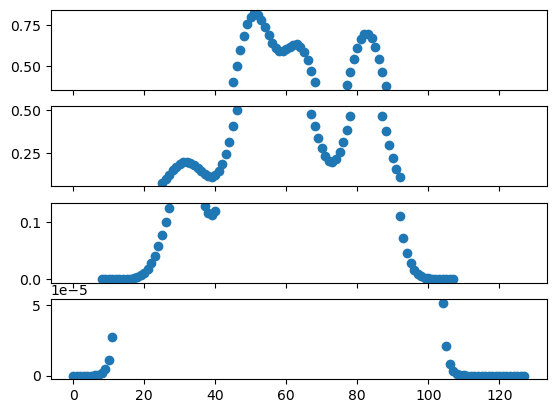

In [11]:
fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    axs[-i - 1].scatter(np.arange(len(local_data[i])), local_data[i])

Notice that we plot the index rather than the spacial coordinate here.

This is a problem, because this will mess up the global tree structure in the local dendrograms.
Let's again compute the local dendrograms:

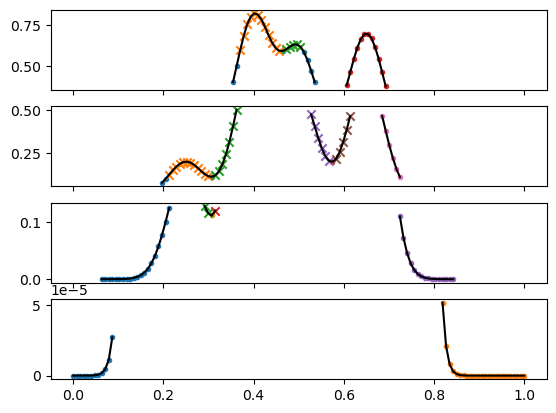

In [12]:
local_dendrograms = [Dendrogram.compute(_data.numpy()) for _data in local_data]

fig, axs = plt.subplots(ntasks, 1, sharex=True)
for i in range(ntasks):
    ax = axs[-i - 1] if ntasks > 1 else axs
    _data = data.copy()
    _data[...] = np.nan
    _data[local_idx[i]] = data[local_idx[i]]
    ax.plot(x.larray, _data.larray, color="black")

    plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)

Have a look at the second panel from the top, where the left and right parts of the structures are not assigned to the same structure anymore.
Now, in 1d, this is obviously not a problem.
We have solved the problem above, by computing the dendrogram only on the local data rather than on an array of the size of the global data with nans, but how do we do this in 2D?

In [13]:
if __name__ == "__main__":
    plt.show()